In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

In [2]:
def get_q_alpha(alpha, k):
    """
    Retorna el valor crítico q de Nemenyi para k clasificadores (k entre 2 y 30).
    """
    if k < 2 or k > 30:
        raise ValueError("El número de clasificadores (k) debe estar entre 2 y 30.")
        
    idx = k - 2  # k empieza en 2
    
    if alpha == 0.10:
        q = [1.645, 2.052, 2.291, 2.460, 2.589, 2.693, 2.780, 2.855, 2.920, 
             2.978, 3.030, 3.077, 3.120, 3.159, 3.196, 3.230, 3.261, 3.291, 
             3.319, 3.346, 3.371, 3.394, 3.417, 3.439, 3.459, 3.479, 3.498, 3.516, 3.533]
    elif alpha == 0.05:
        q = [1.960, 2.343, 2.569, 2.728, 2.850, 2.949, 3.031, 3.102, 3.164, 
             3.219, 3.268, 3.313, 3.354, 3.391, 3.426, 3.458, 3.489, 3.517, 
             3.544, 3.569, 3.593, 3.616, 3.637, 3.658, 3.678, 3.696, 3.714, 3.732, 3.749]
    elif alpha == 0.01:
        q = [2.576, 2.913, 3.113, 3.261, 3.381, 3.481, 3.567, 3.643, 3.710, 
             3.771, 3.825, 3.875, 3.920, 3.962, 4.001, 4.037, 4.071, 4.103, 
             4.133, 4.161, 4.188, 4.213, 4.237, 4.260, 4.282, 4.303, 4.323, 4.342, 4.360]
    else:
        raise ValueError("El valor de alpha debe ser 0.10, 0.05 o 0.01")
        
    return q[idx]

In [3]:
def compute_ranks_and_cd(scores, alpha=0.05, higher_is_better=True):
    N, k = scores.shape
    
    # Invertir el signo para que mayor ACCU reciba el rango 1 (mejor)
    if higher_is_better:
        scores = -scores
        
    # Calcular rangos por dataset (filas) y promediar columnas
    ranks = np.zeros((N, k))
    for i in range(N):
        ranks[i, :] = rankdata(scores[i, :])
        
    mean_ranks = np.mean(ranks, axis=0)
    
    # Diferencia Crítica de Nemenyi
    q = get_q_alpha(alpha, k)
    cd = q * np.sqrt((k * (k + 1)) / (6 * N))
    
    return mean_ranks, cd

In [4]:
def find_cliques(sorted_ranks, cd):
    k = len(sorted_ranks)
    cliques = []
    
    # Evaluar todas las combinaciones posibles
    for i in range(k):
        for j in range(k - 1, i, -1):
            if sorted_ranks[j] - sorted_ranks[i] <= cd:
                cliques.append(list(range(i, j + 1)))
                break
                
    # Quedarse solo con las líneas principales (eliminar redundancias/subconjuntos)
    final_cliques = []
    for c in cliques:
        is_subset = False
        for other in cliques:
            if c != other and set(c).issubset(set(other)):
                is_subset = True
                break
        if not is_subset and c not in final_cliques:
            final_cliques.append(c)
            
    return final_cliques

In [5]:
def plot_cd_diagram(mean_ranks, labels, cd):
    k = len(mean_ranks)
    
    # Ordenar de mejor a peor
    sorted_idx = np.argsort(mean_ranks)
    sorted_ranks = mean_ranks[sorted_idx]
    sorted_labels = [labels[i] for i in sorted_idx]
    
    cliques = find_cliques(sorted_ranks, cd)
    nCliques = len(cliques)
    
    # Dimensiones estilo apaisado
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.set_xlim(-0.35, 1.35)
    ax.set_ylim(0, 115)
    ax.axis('off')
    
    yAxis = 85
    cliqueGap = 6
    rowGap = 8
    
    # 1. Eje principal
    ax.plot([0, 1], [yAxis, yAxis], color='k', lw=1.5)
    
    # 2. Marcas (ticks) del eje hacia arriba con números
    min_tick = int(np.floor(sorted_ranks.min()))
    max_tick = int(np.ceil(sorted_ranks.max()))
    for t in range(min_tick, max_tick + 1):
        x_t = (k - t) / (k - 1)
        ax.plot([x_t, x_t], [yAxis, yAxis + 2], color='k', lw=1.5)
        ax.text(x_t, yAxis + 3, str(t), ha='center', va='bottom', fontsize=12)
        
    # 3. Barra CD superior (con topes laterales) en ROJO
    x_cd_start = 0.5 - (cd / (k - 1)) / 2
    x_cd_end = x_cd_start + (cd / (k - 1))
    cd_y = yAxis + 18
    ax.plot([x_cd_start, x_cd_end], [cd_y, cd_y], color='red', lw=2)
    ax.plot([x_cd_start, x_cd_start], [cd_y - 2, cd_y + 2], color='red', lw=2)
    ax.plot([x_cd_end, x_cd_end], [cd_y - 2, cd_y + 2], color='red', lw=2)
    ax.text(0.5, cd_y + 2, f"CD = {cd:.3f}", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')
    
    # 4. Líneas gruesas para los grupos no significativos (Cliques) en ROJO
    for idx, c in enumerate(cliques):
        x_start = (k - sorted_ranks[c[-1]]) / (k - 1)
        x_end = (k - sorted_ranks[c[0]]) / (k - 1)
        y_c = yAxis - cliqueGap * (idx + 1)
        ax.plot([x_start, x_end], [y_c, y_c], color='red', lw=4.5)
        
    # 5. Dibujar brazos laterales para cada modelo
    mid = int(np.ceil(k / 2))
    startY = yAxis - cliqueGap * (nCliques + 1) - 4
    
    # Mitad Derecha (Mejores Ranks)
    for i in range(mid):
        x = (k - sorted_ranks[i]) / (k - 1)
        y = startY - rowGap * i
        
        ax.plot([x, x, 1.10], [yAxis, y, y], color='k', lw=1.2)
        # Rango flotando en la línea, etiqueta al extremo
        ax.text(1.08, y + 1, f"{sorted_ranks[i]:.2f}", ha='right', va='bottom', fontsize=11)
        ax.text(1.12, y, sorted_labels[i], ha='left', va='center', fontsize=13)
        
    # Mitad Izquierda (Peores Ranks)
    for i in range(mid, k):
        x = (k - sorted_ranks[i]) / (k - 1)
        pos_idx = (k - 1 - i)
        y = startY - rowGap * pos_idx
        
        ax.plot([x, x, -0.10], [yAxis, y, y], color='k', lw=1.2)
        # Rango flotando en la línea, etiqueta al extremo
        ax.text(-0.08, y + 1, f"{sorted_ranks[i]:.2f}", ha='left', va='bottom', fontsize=11)
        ax.text(-0.12, y, sorted_labels[i], ha='right', va='center', fontsize=13)
        
    plt.tight_layout()
    plt.show()

Generando diagrama CD para el modelo NO LINEAL (ACCU)...


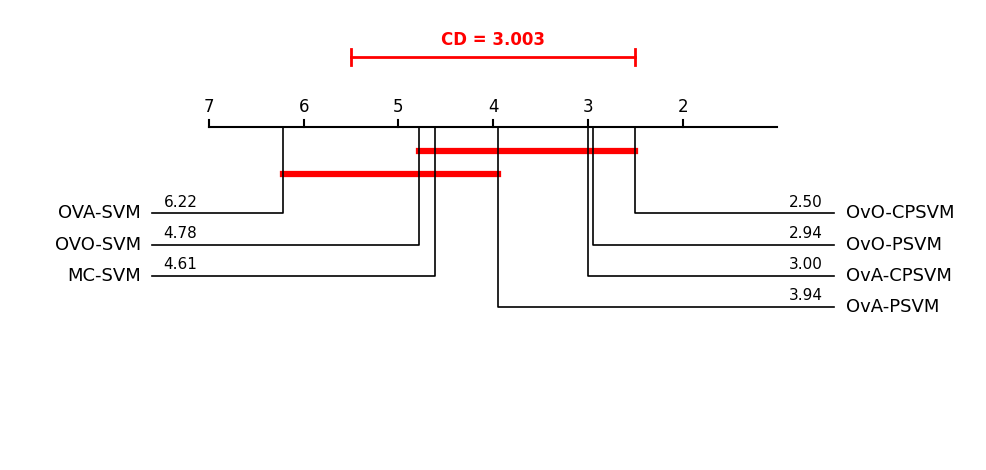

In [6]:
if __name__ == "__main__":
    
    Ker = 2 # Cambia Ker a 1 para evaluar el modelo LINEAL o a 2 para NO LINEAL
    
    if Ker == 1:
        
        MC_SVM    = [96.00, 53.75, 98.89, 54.74, 75.00, 71.96, 96.86, 70.72, 90.91]
        OVA_SVM   = [94.67, 56.25, 98.33, 60.80, 73.80, 49.60, 97.20, 76.36, 92.68]
        OVO_SVM   = [98.00, 64.38, 98.33, 63.12, 74.20, 89.02, 97.52, 83.45, 95.58]
        OvA_PSVM  = [93.33, 54.38, 99.52, 61.26, 72.80, 56.98, 96.54, 71.51, 92.68]
        OvO_PSVM  = [98.00, 57.50, 98.33, 64.94, 74.40, 89.21, 97.20, 82.40, 96.02]
        OvA_CPSVM = [96.00, 58.75, 98.89, 61.23, 75.60, 57.75, 96.87, 72.43, 93.33]
        OvO_CPSVM = [98.00, 59.38, 98.30, 64.48, 75.60, 85.80, 97.20, 82.53, 96.41]
        print("Generando diagrama CD para el modelo LINEAL (ACCU)...")
        
    else:
        
        MC_SVM    = [97.33, 85.00, 98.89, 73.77, 75.80, 98.86, 97.36, 85.02, 98.33]
        OVA_SVM   = [97.33, 84.38, 98.33, 73.74, 74.00, 99.24, 97.36, 85.55, 97.50]
        OVO_SVM   = [98.00, 85.00, 98.89, 73.70, 74.60, 99.27, 97.53, 86.07, 97.40]
        OvA_PSVM  = [98.67, 85.00, 100.00, 74.22, 74.40, 99.43, 97.36, 86.73, 97.58]
        OvO_PSVM  = [98.67, 85.63, 99.44, 74.76, 74.40, 99.62, 97.53, 86.74, 97.92]
        OvA_CPSVM = [97.33, 84.38, 100.00, 75.63, 75.60, 99.81, 97.53, 86.99, 97.84]
        OvO_CPSVM = [98.67, 84.38, 100.00, 74.76, 75.40, 99.81, 97.53, 87.12, 98.14]
        print("Generando diagrama CD para el modelo NO LINEAL (ACCU)...")

    # Agrupar los datos en la matriz 'scores'
    scores = np.column_stack((MC_SVM, OVA_SVM, OVO_SVM, OvA_PSVM, OvO_PSVM, OvA_CPSVM, OvO_CPSVM))
    labels = ['MC-SVM', 'OVA-SVM', 'OVO-SVM', 'OvA-PSVM', 'OvO-PSVM', 'OvA-CPSVM', 'OvO-CPSVM']
    
    # Computar rangos y CD (Usando alfa = 0.05 por defecto)
    mean_ranks, cd = compute_ranks_and_cd(scores, alpha=0.05, higher_is_better=True)
    
    # Generar el gráfico
    plot_cd_diagram(mean_ranks, labels, cd)